<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-10 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Simple AutoEncoders with Image Data </h2> </html>

Here is a simple autoencoder with just the dense layers.


Load the data and import the libraries.

In [ ]:
# Your code to import matplotlib, pandas and numpy libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#
#
#
#
#


_______________________![image.png](attachment:a4e07154-e766-4e74-a203-c09e7605ea7b.png)

In [ ]:
import tensorflow as tf
from tensorflow import keras



__________________![image.png](attachment:06d151d2-f461-411d-8325-a4a6287cfd48.png)

In [ ]:
print (tf.__version__)

2.20.0


____________________![image.png](attachment:3ff556fc-1f76-4be4-a216-1e8aecd11e54.png)

In [ ]:
from keras.layers import Input, Dense
from keras.models import Model

from keras.datasets import mnist


In [ ]:
# Your code to load MNIST data and store it in variables x_train, x_test.
# Note -  we do not need labels as it's autoencoder.

# Load MNIST data
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values (0–255 → 0–1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape for autoencoder (flatten images: 28x28 → 784)
x_train = x_train.reshape((len(x_train), -1))
x_test = x_test.reshape((len(x_test), -1))

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
#



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 784)
x_test shape: (10000, 784)


______________________![image.png](attachment:74823cdf-09eb-4a7a-8a39-8c306d6de031.png)

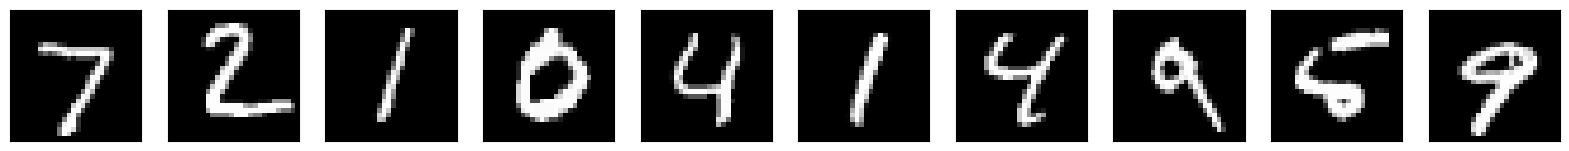

In [ ]:
%matplotlib inline

n=10
plt.figure(figsize=(20,4))
for i in range(n):

  ax= plt.subplot(2,n,i+1)
  plt.imshow(x_test[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

plt.show()


In [ ]:
# Your code to
# normalise train data - Divided by 255

x_train = x_train.astype("float32") / 255.0


# normalise test data - Divided by 255
x_test = x_test.astype("float32") / 255.0
#


<html> <h3 style="font-style:italic; color:blue;"> Basic AutoEncoder : </h3> </html>

Build a basic symmetric encoder-decoder network that recreates the image.  
This network could be used in dimensionaliry reduction or feature learning.


________________________![image.png](attachment:de80ae8e-d8d5-4cfc-a51b-a2f7d50dc7c2.png)

In [ ]:
from tensorflow.keras.layers import Dense, Reshape, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD

In [ ]:
from tensorflow.keras.layers import InputLayer, Dense, Reshape, Flatten
from tensorflow.keras.models import Sequential

encoder = Sequential()
encoder.add(InputLayer(input_shape=(784,))) # Explicitly define the input layer
encoder.add(Dense(128, activation='relu'))
encoder.add(Dense(64, activation='relu'))
encoder.add(Dense(32, activation='relu'))
encoder.add(Dense(16, activation='relu'))
encoder.add(Dense(25, activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
# Your code to print your Encoder model
encoder.summary()
#


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │           425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,769 (436.60 KB)

 Trainable params: 111,769 (436.60 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Your OWN Encoder model should be printed here
# Please do not copy the model below

In [ ]:
decoder = Sequential()
decoder.add(Dense(50,input_shape=[25],activation='relu'))

# Add as many layers in the Decoder as you want.
# Reember - Encoder and Decoder must be symmetric.
decoder.add(Dense(100, activation='relu'))
decoder.add(Dense(200, activation='relu'))

# Final reconstruction layer
decoder.add(Dense(28 * 28, activation="sigmoid"))
decoder.add(Reshape([28, 28]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Your code to print the Decoder model
decoder.summary()
#


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 50)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 784)            │       157,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,184 (719.47 KB)

 Trainable params: 184,184 (719.47 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Your OWN Decoder model should be printed here
# Please do not copy the model below

____________________![image.png](attachment:a94c2e5b-e27d-4e12-84c9-116a2f70e393.png)

In [ ]:
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

# Define the input layer for the entire autoencoder
input_img = Input(shape=(784,))

# Pass the input through the encoder
encoded_img = encoder(input_img)

# Pass the encoded output through the decoder
decoded_img = decoder(encoded_img)

# Create the autoencoder model using the functional API
autoencoder = Model(inputs=input_img, outputs=decoded_img)

In [ ]:
# Your code to print the Autoencoder model
autoencoder.summary()
#
#

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 25)             │       111,769 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28)         │       184,184 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,953 (1.13 MB)

 Trainable params: 295,953 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Your OWN Autoencoder model should be printed here

In [ ]:
#SGD?

from tensorflow.keras.optimizers import SGD



In [ ]:
autoencoder.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

___________________![image.png](attachment:c8684fc7-fcb0-48bf-87e8-f70857a0fc4e.png)

In [ ]:
history = autoencoder.fit(x_train, x_train.reshape(-1, 28, 28), epochs=20, validation_data=(x_test, x_test.reshape(-1, 28, 28)))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.0536 - loss: 0.6896 - val_accuracy: 0.0522 - val_loss: 0.6860
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.0549 - loss: 0.6821 - val_accuracy: 0.0545 - val_loss: 0.6780
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.0553 - loss: 0.6728 - val_accuracy: 0.0545 - val_loss: 0.6667
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.0531 - loss: 0.6562 - val_accuracy: 0.0519 - val_loss: 0.6405
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.0528 - loss: 0.5103 - val_accuracy: 0.0537 - val_loss: 0.0594
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.0571 - loss: 0.0100 - val_accuracy: 0.0691 - val_loss: 0.0051
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.0749 - loss: 0.0049 - val_accuracy: 0.0766 - val_loss: 0.0048
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.0535 - loss: 0

____________________![image.png](attachment:30a3bc58-49bd-4849-8c76-e2551d3a033b.png)

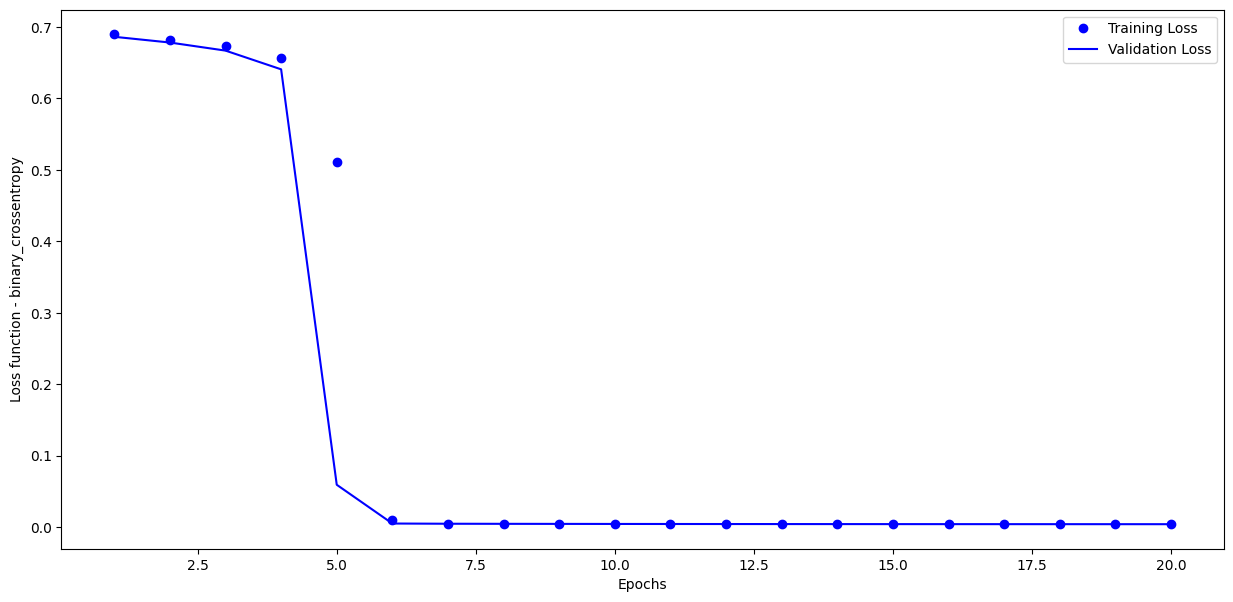

In [ ]:
from keras.src.trainers import epoch_iterator
losses = history.history['loss']
val_losses = history.history['val_loss']
epochs = range(1, len(losses) + 1)

plt.figure(num =1,figsize=(15, 7))
plt.plot(epochs, losses,'bo', label='Training Loss')
plt.plot(epochs, val_losses,'b', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss function - binary_crossentropy')
plt.legend()
plt.show()

___________________![image.png](attachment:b2f19fbc-57fa-40f7-80a1-336642829de1.png)

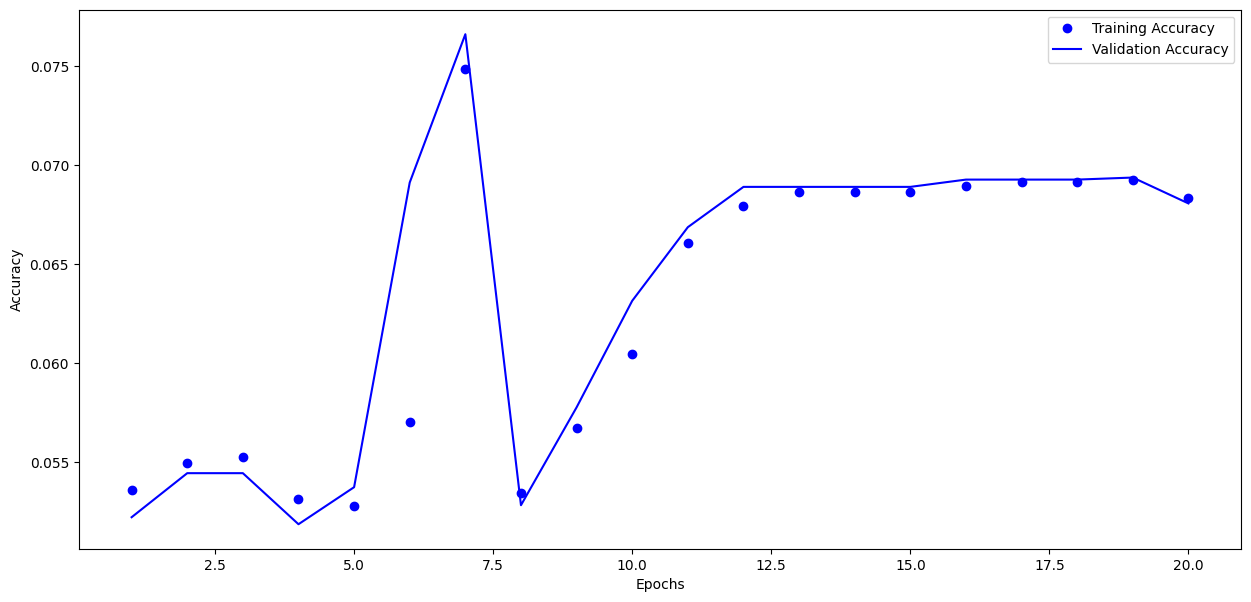

In [ ]:
accuracy_array = history.history['accuracy']
val_accuracy_array = history.history['val_accuracy']
epochs = range(1, len(accuracy_array) + 1)

plt.figure(num =1,figsize=(15, 7))
plt.plot(epochs, accuracy_array,'bo', label='Training Accuracy')
plt.plot(epochs, val_accuracy_array,'b', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

_______________________![image.png](attachment:39f152ac-8692-403f-a1c4-3a71fe4fd978.png)

<html> <h3 style="font-style:italic; color:blue;"> AutoEncoders for Denoising Images : </h3> </html>

Use the same digit data set. Add Gaussian noise to it to train an autoencoder that removes noise. Test the noisy samples.


______________________![image.png](attachment:66c883c0-27ea-473a-bfbf-adf60d8af39f.png)

In [ ]:
#GaussianNoise?

___________________![image.png](attachment:daef4479-63f7-4a6a-9927-be13f2230632.png)

In [ ]:
# Plot the original and noisy images

_______________________![image.png](attachment:4013cb09-7c0a-4cc7-b208-31bda1d0f668.png)

____________________![image.png](attachment:2e2bac52-3120-4879-9117-f71bdf1ac965.png)

_____________________![image.png](attachment:003958e0-35f7-4d32-8faf-b9486b5d206f.png)

_________![image.png](attachment:dd745f81-2f9e-4b45-b030-3a4529ea6f1d.png)

______________________![image.png](attachment:cf4f913b-10d4-47b9-9d91-b22fd1c175fa.png)

<html> <h4 style="font-style:italic; color:blue;"> Create a noise removal autoencoder and train it </h4> </html>

- Again similar to above it is a symmetric dense network.
- Gaussian noise is added at the input so that the network sees noisy images and is able to map it to the clean outputs.


### Input - Images with noise
### Labels - Clean images.


In [ ]:
from tensorflow.keras.layers import GaussianNoise, InputLayer, Flatten
from tensorflow.keras.models import Sequential

# Encoder

encoder = Sequential()
encoder.add(InputLayer(input_shape=(28, 28))) # Explicitly define the input layer
encoder.add(Flatten()) # Flatten now does not need input_shape
encoder.add(GaussianNoise(0.2)) # We are adding noise to make input as noisy images

# Add layers of Encoder network. You could use the same number of layers as you created earlier
#
#
#
#

print(encoder.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 784)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Your OWN Encoder model should be printed here
# Please do not copy the model below

In [ ]:
decoder = Sequential()
decoder.add(Dense(50,input_shape=[25],activation='relu'))

# Add layers of the Decoder network. You could use the same number of layers as you created earlier
# Reember - Encoder and Decoder must be symmetric

#
#
#


decoder.add(Dense(28 * 28, activation="sigmoid"))
decoder.add(Reshape([28, 28]))

print(decoder.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 50)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 784)            │        39,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,284 (161.27 KB)

 Trainable params: 41,284 (161.27 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Your OWN Decoder model should be printed here
# Please do not copy the model below

_________________________![image.png](attachment:b8742807-43dd-41a1-a461-c2a4455e6d07.png)

In [ ]:
# Your code to print the Autoencoder model

#

In [ ]:
# Your OWN Autoencoder model should be printed here

In [ ]:
# Your code to compile the 'noise_remover' model with the same parameters as earlier

# noise_remover.compile( ................  )


In [ ]:
# Your code to fit 'noise_remover' model with the same parameters as earlier

# history_2 = ..........................


In [ ]:
# Hint: Use (copy and modify) the code from the cells above

___________________![image.png](attachment:05682556-9ec1-46c6-85d5-3db97ba3c04f.png)

___________________________![image.png](attachment:43697532-dcb7-41bf-a1fa-6f630f5d4a29.png)

______________________![image.png](attachment:9dbf1489-73d6-4480-adc7-0ced14e0c9dd.png)

______________________![image.png](attachment:a5bc2008-bc25-45e7-97ba-ae44dffae6ed.png)

_______![image.png](attachment:505ed502-6fd8-4f58-a27f-44a804f20493.png)

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

 - Put the Encoder, Decoder and Basic Autoencoder models using summary() in your lab logbook.

Ensure that no code or other information is added to the logbook and that only required information is present. Marks will not be awarded if anything else is found in the logbook or instructions are not clearly followed.

NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB OR ONEDRIVE.